In [1]:
# Re-import edits from itf.py so the notebook stops using the old version
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..") #tells python to go one folder up
from src.ingest.itf import parse_itf, census_itf #brings in my function

In [2]:
%%time
#this loads the dataset, and verifies its length
lines = open("../data/itf_slice100k.txt").read().splitlines() #this line simply sets my simplified dataset equal to "lines:
print(len(lines)) #prints how many lines, should be 100,000 for itf)slice100k.txt
#after first test, printed the correct number of lines

100000
CPU times: user 14 ms, sys: 8.46 ms, total: 22.5 ms
Wall time: 604 ms


In [3]:
%%time
#this cell will allow me to approx eyeball the raw structure, as it's a new file
for line in lines[:5]: #initiates a for loop, that will run for the first five lines
    print(repr(line)) #simply prints out everying on the line

'     /7239   4C2015 05 23.30928 11 55 25.17 -01 46 36.9          23.7 z1     T09'
'     /7239   4C2015 05 23.32686 11 55 25.34 -01 46 36.1          23.7 z1     T09'
'     /7239   4C2015 05 23.34140 11 55 25.49 -01 46 35.4          23.5 z1     T09'
'     /2050   4C2016 07 12.54696 23 31 53.92 -00 17 11.8          23.1 z1     T09'
'     /2050   4C2016 07 12.56833 23 31 54.24 -00 17 08.9          22.0 z1     T09'
CPU times: user 760 μs, sys: 0 ns, total: 760 μs
Wall time: 561 μs


In [4]:
%%time
#Cell copied over from the parsing of the 3I astrometry. Slightly modified.
import pandas as pd

rows = []
skipped_short = 0 #this creates a counter for lines we couldn't parse
skipped_pair = 0
for line in lines:
    if len(line) < 80: #if the line is shorter than 80
        skipped_short += 1
        continue
    if line[14].islower():
        skipped_pair += 1
        continue
    #the below is a fix to make the parser detect if there is a shift from an S at the start of the date, from if the observer was a space telescope. This should fix that error.
    off = 0 if line[15].isdigit() else 1
    rows.append({ #builds a list for the current line of all of its important info (normalizes data)
        "desig":    line[:12].strip(),
        "date_str": line[15+off:32+off].strip(),
        "ra_str":   line[32+off:44+off].strip(),
        "dec_str":  line[44+off:56+off].strip(),
        "mag_str":  line[65+off:70+off].strip(),
        "obscode":  line[77+off:80+off],
    })

df = pd.DataFrame(rows) #turns the list into a table
print(len(df), "parsed |", skipped_short, "short |", skipped_pair, "continuation") #prints how many rows were skipped, and how many made it to the table
df.head() #shows the first five rows of now parsed data

97746 parsed | 0 short | 2254 continuation
CPU times: user 230 ms, sys: 29.9 ms, total: 260 ms
Wall time: 295 ms


,desig,date_str,ra_str,dec_str,mag_str,obscode
0,/7239,2015 05 23.30928,11 55 25.17,-01 46 36.9,23.7,T09
1,/7239,2015 05 23.32686,11 55 25.34,-01 46 36.1,23.7,T09
2,/7239,2015 05 23.34140,11 55 25.49,-01 46 35.4,23.5,T09
3,/2050,2016 07 12.54696,23 31 53.92,-00 17 11.8,23.1,T09
4,/2050,2016 07 12.56833,23 31 54.24,-00 17 08.9,22.0,T09


In [5]:
%%time
#This cell will measure the memory that all lines take up

gb = df.memory_usage(deep=True).sum() / 1e9 #counts the true cost of everything, includeing strings, it then totals all columns, then converts bytes to GB
print(round(gb, 3), "GB for 100k lines")

0.034 GB for 100k lines
CPU times: user 148 ms, sys: 3.45 ms, total: 151 ms
Wall time: 162 ms


In [6]:
%%time
#this cell will extrapolate based off all the numbers/data i've collected so far, to calculate how long it will take, and how much space it will take up

TOTAL = 9354883 #the total amount of lines
t_slice = 0.544 #the amount of time it took to parse 100k lines
gb_slice = 0.034 #the amount of data used for the 100k lines

scale = TOTAL / 100000 #this determines what we need to scale our current data and time values by
print("projected parse time:", round(t_slice * scale / 60, 1), "minutes") #calculates how long its expected to parse by multipling our current value by the scale factor, and then converting it to minutes, as its currently in milliseconds
print("projected dataframe:", round(gb_slice * scale, 1), "GB") #does the same as above, but for gigabytes 

projected parse time: 0.8 minutes
projected dataframe: 3.2 GB
CPU times: user 355 μs, sys: 75 μs, total: 430 μs
Wall time: 364 μs


In [7]:
%%time
#"flag" census

from collections import Counter #imports python's counter
flags = Counter(line[14] for line in lines if len(line) >= 80) #this parses through all 100000 lines, and adds the charachter at index 14 to the flag variable, whenever the length is above or equal to 80 length
print(flags.most_common(10)) #prints out the 10 most common flags


[('C', 95470), ('S', 2254), ('s', 2254), ('B', 16), (' ', 6)]
CPU times: user 21.2 ms, sys: 0 ns, total: 21.2 ms
Wall time: 41.4 ms


In [8]:
%%time
#This is a validator cell, to ensure that every weird line gets caught before going to the next few cells
looks_ok = df["ra_str"].str.match(r"^\d{2} \d{2} \d{2}") #this line tests every entry in the ra_str column against a pattern, only passing lines that pass the pattern, testing each invididual row. The pattern itself checks to ensure that starting at the very beginning of the string, there are exactly 3 pairs of two digits seperated by spaces.
print((~looks_ok).sum(), "suspicious rows") #the ~ means not, and flips every true to false and visa versa, so looks ok then marks the rows that failed the test, so we know how many failed without creating a new variable. .sum simply counts how many of these failures there are, and the print tells me the quantity
df[~looks_ok].head() #This line prints out the first five rows that didn't pass the test.

0 suspicious rows
CPU times: user 69.3 ms, sys: 913 μs, total: 70.3 ms
Wall time: 192 ms


,desig,date_str,ra_str,dec_str,mag_str,obscode


In [9]:
%%time
#this cell will preform structural checks
print(df["desig"].value_counts().head(10)) #Will print the "biggest" tracklets in the file
print(df["obscode"].value_counts().head(10)) #Which observatories are in the head of the file
print(df["desig"].nunique(), "distinct designations in file slice") #prints out the number of different objects in this file

desig
0001198    32
0003065    30
0001935    28
0003154    26
0000781    23
0001501    23
06AQUV     23
0001508    22
0000533    21
0023651    21
Name: count, dtype: int64
obscode
705    81145
699    10931
C51     2254
Z18      846
568      568
Z32      468
608      183
J75      156
W92      101
I41       73
Name: count, dtype: int64
45623 distinct designations in file slice
CPU times: user 58.7 ms, sys: 2.29 ms, total: 61 ms
Wall time: 70.2 ms


In [10]:
df_s, stats_s = parse_itf("../data/itf_slice100k.txt") #runs the parsing function on the 100k line practice file, gives the two things the function returns names
print(stats_s) #Shows the counts
print(len(df_s) == 97746, ": module gives the same answer as cell from tuesday") #compares how many lines were actually parsed to tuesday's values, should print true

{'parsed': 97746, 'skipped': 2254}
True : module gives the same answer as cell from tuesday


In [11]:
#%%time
#df, stats = parse_itf("../data/itf.txt") #parses it
#print(stats) #prints the stats
#print(len(df), "rows in full ITF table") #prints num rows

{'parsed': 9290214, 'skipped': 64669, 'bad_ra': 0}
[('F51', 2720677), ('W84', 1197169), ('G96', 1085281), ('F52', 1038077), ('T09', 871810), ('V00', 485629), ('705', 462223), ('691', 259477), ('309', 152324), ('703', 127381), ('644', 102570), ('699', 92473), ('568', 72077), ('695', 67819), ('807', 64994)]
42.2 percent from top two
1858 3
1889 1
1901 1
1920 6
1950 2
1951 6
1953 14
1954 12
1955 14
1956 8
1960 6
1974 2
1975 2
1976 8
1977 2
1978 12
1981 18
1982 13
1983 8
1984 2
1985 8
1986 4
1987 2
1988 38
1990 219
1991 864
1992 675
1993 1217
1994 1593
1995 2691
1996 2776
1997 2768
1998 24404
1999 13181
2000 37221
2001 42256
2002 35794
2003 58483
2004 46017
2005 308723
2006 335316
2007 195071
2008 111901
2009 92749
2010 140932
2011 149744
2012 149791
2013 233972
2014 531295
2015 756361
2016 626673
2017 525470
2018 313563
2019 821873
2020 543218
2021 737552
2022 571574
2023 522220
2024 566167
2025 548315
2026 237383
2593332 designations | mean 3.58 | median 3.0


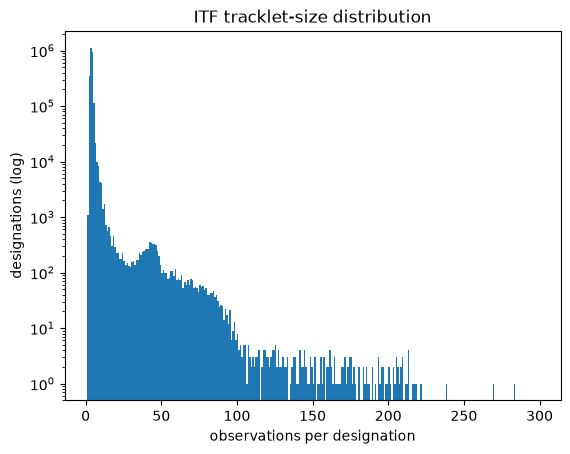

283
[('tnoa002', 283), ('soho181', 269), ('tnoa009', 238), ('RL00TZQ', 221), ('RL00U5M', 218)]


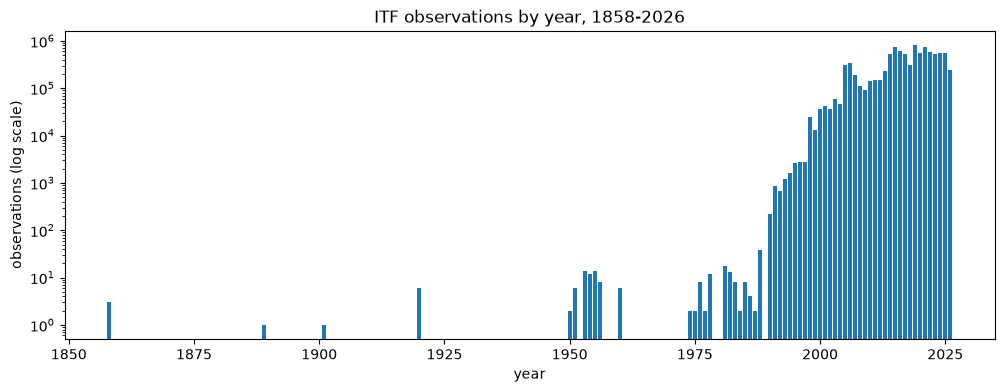

CPU times: user 27.6 s, sys: 765 ms, total: 28.4 s
Wall time: 29.8 s


In [18]:
%%time
import numpy as np
import matplotlib.pyplot as plt

obs, years, sizes, stats = census_itf("../data/itf.txt") #runs the function
print(stats) #prints the rsults of the function
print(obs.most_common(15)) #prints the 15 most common observatories throughout the ENTIRE file
top2 = sum(n for _, n in obs.most_common(2)) #creates top2, with the top 2 observatories
print(round(top2 / stats["parsed"] * 100, 1), "percent from top two") #Calculaes and prints what percent of all observations were made by the top two observatories

for y in sorted(years): #the groth history of the file, in year order
    print(y, years[y])

counts = np.fromiter(sizes.values(), dtype=np.int32) #counter values into compact number array
print(len(counts), "designations | mean", round(counts.mean(), 2), "| median", np.median(counts))

#the below is all to create a plot of this
plt.hist(counts, bins=range(1, 300))
plt.yscale("log")
plt.xlabel("observations per designation"); plt.ylabel("designations (log)")
plt.title("ITF tracklet-size distribution")
#plt.savefig("../figures/itf_tracklet_sizes_V1.png", dpi=150)
plt.show()
print(max(counts))
print(sizes.most_common(5))

year_nums = sorted(int(y) for y in years) #turns counter keys into real numbers, in order
year_counts = [years[str(y)] for y in year_nums] #gets each year's tally back, in the same order as the counter keys
#the below is all for the second graph, for the year data
plt.figure(figsize=(12, 4))
plt.bar(year_nums, year_counts)
plt.yscale("log")
plt.xlabel("year")
plt.ylabel("observations (log scale)")
plt.title("ITF observations by year, 1858-2026")
plt.savefig("../figures/itf_by_year_V1.png", dpi=150)
plt.show()